# INTRODUCCIÓN

Este Notebook es un análisis de una tienda de mayoreo, la cual contiene infromación de múltiples productos de múltiples fabricantes (Panel Data)

Se estructura en el siguiente orden:


1. Limpieza de Datos
2. Agrupado mensual
3. Estadística Descriptiva
4. Ventas anuales por Fabricante
5. Análisis Mensual de últimos 12 meses
6. Matriz de Covarianza y Correlación de productos top
7. Análisis Mensual de Fabricante 1
8. Gráfica de Tiempo de producto top
9. Modelo de regresión lineal simple
10. Modelo de regresión múltiple

#Inicialización de Database

In [1]:
#Librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
#Inicialización de Dataset
df = pd.read_excel("/content/DATA_VENTAS.xlsx")

#Descripción incial
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3296 entries, 0 to 3295
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CORTE                    3296 non-null   object        
 1   FABRICANTE               3296 non-null   object        
 2   ID                       3296 non-null   object        
 3   PRODUCTO                 3296 non-null   object        
 4   AÑO1                     3296 non-null   int64         
 5   SEMANA                   3296 non-null   int64         
 6   MES                      3296 non-null   int64         
 7   FECHAW                   3296 non-null   datetime64[ns]
 8   FECHAM                   3296 non-null   datetime64[ns]
 9   VENTA_VALOR              3296 non-null   float64       
 10  LITROS                   3296 non-null   int64         
 11  PRECIO_UNITARIO_LITRO    3293 non-null   float64       
 12  PAQUETES                 3296 non-

A primera vista del dataset, se observa que contiene 3,296 filas y 15 columnas. La mayoría de las columnas están completas, a excepción de "PRECIO_UNITARIO_LITRO", la cual tiene 3 valores nulos.

In [3]:
#Columnas con valores nulos
df[df['PRECIO_UNITARIO_LITRO'].isnull()]

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1309,TN,FAB1,Leche Clasica Semi 1 L,FAB1_Leche Clasica Semi 1 L,2024,16,4,2024-04-15,2024-04-01,0.0,192,NaN,16,NaN,12
1659,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2025,4,1,2025-01-20,2025-01-01,-268.0,0,NaN,0,NaN,12
3268,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,17,4,2025-04-21,2025-04-01,0.0,0,NaN,0,NaN,12


Observando las columnas, se identifica que son de 3 productos distintos y tienen vacíos en el precio unitario de litro ya que este se calcula con las columnas de Venta del producto y Litros que se vendieron.

Se calcula de la siguiente forma:

$\frac{Venta}{Litros}$

Sabiendo esto, al tener que calcularlo y teniendo valores con 0, causa un error y no es posible determinarlo.

En este caso, se mantendrán en el dataset para no perder información y no será afectada, ya que se realizará un análisis a nivel mensual y se agruparán los datos.

In [4]:
df.groupby('PRODUCTO')['ID'].nunique().sort_values(ascending=False).head(50)

,ID
PRODUCTO,
FAB1_1L Sel Des Deslactosada,1
FAB1_1L Sele En Selecta Entera,1
FAB1_Leche Clasica Deslactosada 1 L,1
FAB1_Leche Clasica Deslactosada Light 1 L,1
FAB1_Leche Clasica Entera 1 L,1
FAB1_Leche Clasica Extra Deslactosada 1 L,1
FAB1_Leche Clasica Light 1 L,1
FAB1_Leche Clasica Semi 1 L,1
FAB2_ 100 70+30,1


En este nivel de granularidad entre ID y Producto, se observa que no existen duplicados.

Ahora, se buscará analizar a nivel de granularidad de Fabricante, ID, Producto y Concatenado Semanal con el propósito de que no exista un duplicado de semanas o un error a mayor profundidad que en el agrupado mensual ya no sea posible visualizar.

In [5]:
df[df.duplicated(
    subset=['FECHAW', 'FABRICANTE', 'ID'],
    keep=False
)].sort_values(
    ['FABRICANTE', 'ID', 'FECHAW']
).head(6)

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1629,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,211303.67,9336,22.633212,778,271.598548,12
1630,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,8397.00,396,21.204545,33,254.454545,12
1631,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,210346.78,10116,20.793474,843,249.521684,12
1632,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,80793.00,3924,20.589450,327,247.073394,12
1633,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,40552.91,1884,21.524899,157,258.298790,12
1634,TN,FAB2,Des Light Deslactosada Light 1L,FAB2_ Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,161971.97,7716,20.991702,643,251.900420,12


Se ha identificado registros dobles para una misma combinación de fabricante, producto y semana. Revisando los valores, no parece ser un duplicado ya que no son dos registros con los mismos valores.

Ya que la variable de venta y volumen son acumulables y se realizará posteriormente para un agrupado mensual, los registros se van a mantener.

# Agrupado Mensual

Una vez realizada la limpieza y transformación de datos, se busca hacer un agrupado a nivel mensual que permita hacer un análisis más generalizado.

In [6]:
monthly = (
    df.groupby(
        [
            'CORTE',
            'FABRICANTE',
            'ID',
            'PRODUCTO',
            'AÑO1',
            'MES',
            'FECHAM'
        ],
        as_index=False
    )
    .agg({
        'VENTA_VALOR': 'sum',
        'LITROS': 'sum',
        'PAQUETES': 'sum',
        'UNIDADES_EN_PAQUETE': 'first'
    })
)

monthly['PPU_Litro'] = (
    monthly['VENTA_VALOR'] / monthly['LITROS']
)

monthly['PPU_Paquete'] = (
    monthly['VENTA_VALOR'] / monthly['PAQUETES']
)

Tras realizar el agrupado mensual de ventas y unidades a nivel ID, Producto, Fabricante y Fecha Mensual, se recalcula el precio unitario por litro y por paquete. Esto se debe a que, se busca obtener el valor de precio unitario por litro de forma mensual, por lo que hacer un promedio de los precios obtenidos anteriormente no sería adecuado.



In [7]:
monthly.duplicated(
    subset=['FABRICANTE', 'ID', 'FECHAM', 'PRODUCTO']
).sum()

np.int64(0)

In [8]:
monthly.isnull().sum()

,0
CORTE,0
FABRICANTE,0
ID,0
PRODUCTO,0
AÑO1,0
MES,0
FECHAM,0
VENTA_VALOR,0
LITROS,0
PAQUETES,0


Al hacer el agrupado mensual, se ha desaparecido los valores vacíos y esto es adecuado ya que se recalculan los precios unitarios tanto de litro como de unidad de forma mensual, por lo que las semanas que daban un problema ya fueron tratados y se comprueba que no existen valores vacíos.

También se observa que el empalme de datos del producto de Fabricante 2 han sido agrupados de manera correcta y que ya no existe el error de información.


Una vez realizado esto, se busca entender los datos utilizando la estadística descriptiva. Esto nos permite entender los rangos de datos, si existe algún sesgo o valor atípico en los datos.

Cabe aclarar que es un agrupado de todos los productos y no desglosado, esto es para darse una idea general del comportamiento general de la categoría.

## Estadística Descriptiva

In [9]:
monthly[
    ['VENTA_VALOR', 'LITROS', 'PAQUETES',
     'PPU_Litro', 'PPU_Paquete']
].describe()

,VENTA_VALOR,LITROS,PAQUETES,PPU_Litro,PPU_Paquete
count,7.100000e+02,710.000000,710.000000,710.000000,710.000000
mean,3.229523e+06,159917.019718,13324.498592,20.771895,249.437445
std,2.881898e+06,144507.543090,12043.748466,3.138157,37.797689
min,-3.278010e+03,-144.000000,-12.000000,1.303922,15.647059
25%,1.157783e+06,57192.000000,4759.250000,18.937465,227.249583
50%,2.063759e+06,98820.000000,8235.000000,20.416099,245.374141
75%,4.761391e+06,243660.000000,20305.000000,22.402781,269.068687
max,1.588330e+07,787368.000000,65614.000000,32.540592,390.487104


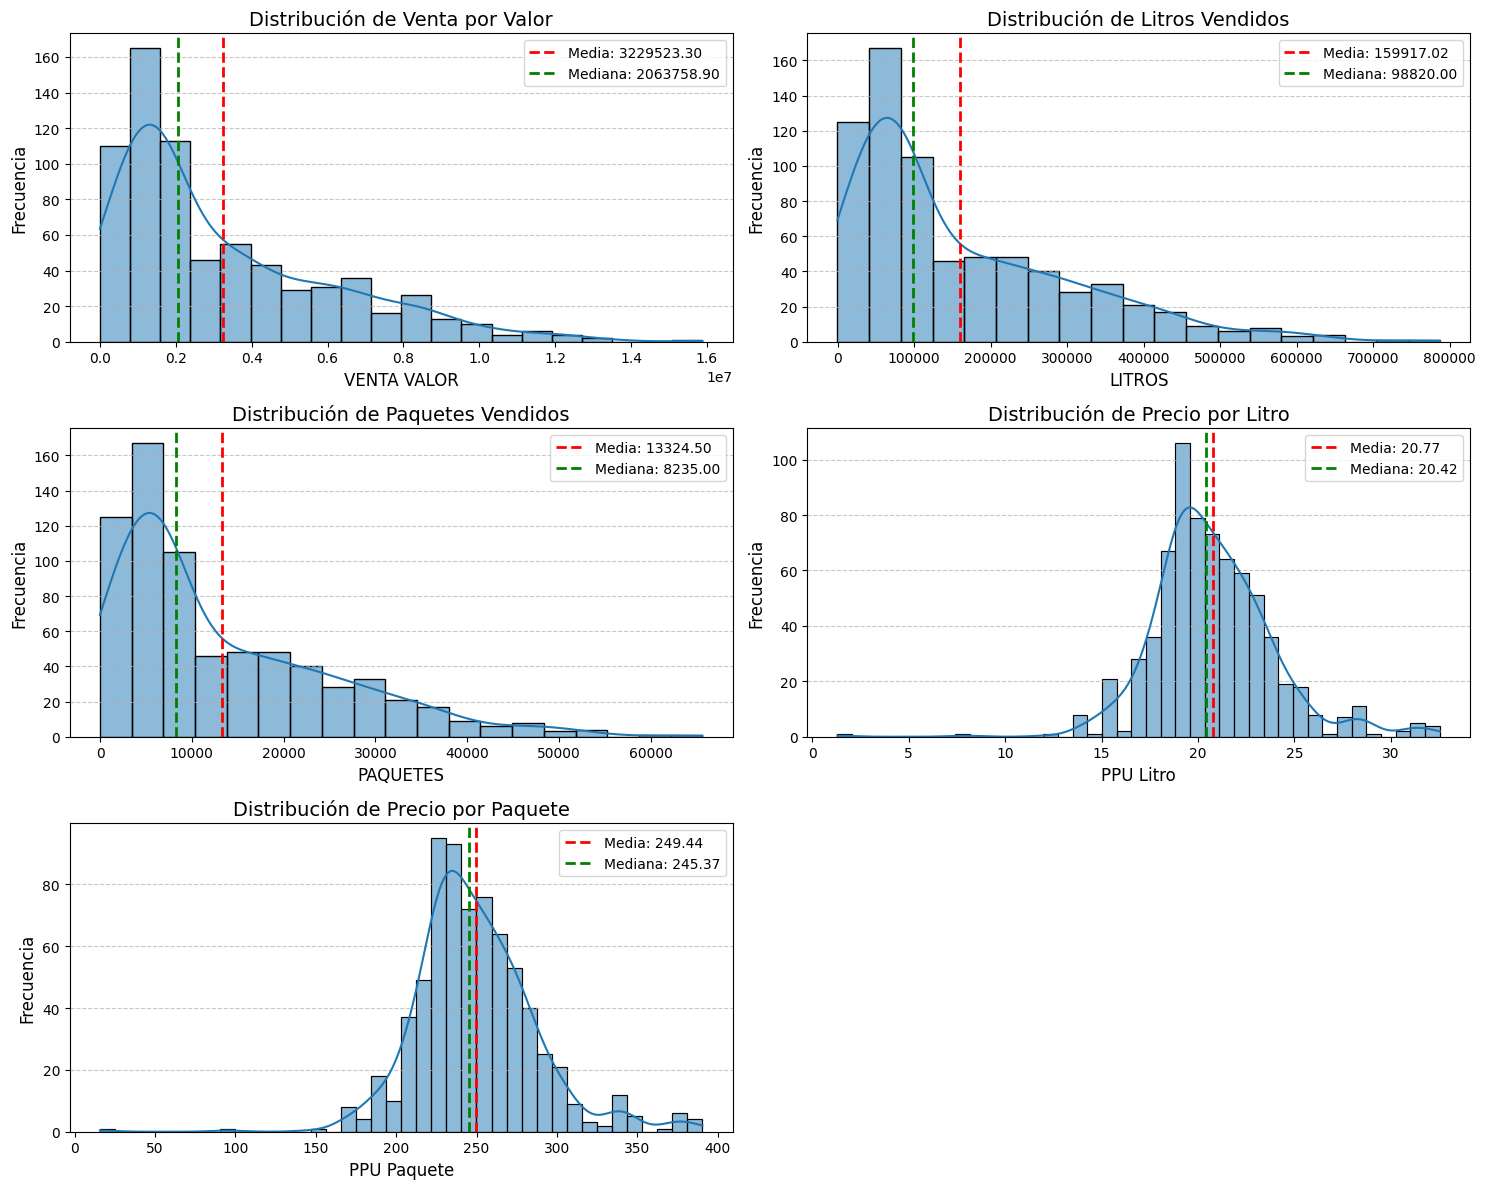

In [10]:
columns_to_plot = [
    'VENTA_VALOR', 'LITROS', 'PAQUETES',
    'PPU_Litro', 'PPU_Paquete'
]

plot_titles = {
    'VENTA_VALOR': 'Distribución de Venta por Valor',
    'LITROS': 'Distribución de Litros Vendidos',
    'PAQUETES': 'Distribución de Paquetes Vendidos',
    'PPU_Litro': 'Distribución de Precio por Litro',
    'PPU_Paquete': 'Distribución de Precio por Paquete'
}

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(15, 12)
)

axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(monthly[col], kde=True, ax=axes[i])
    axes[i].set_title(plot_titles[col], fontsize=14)
    axes[i].set_xlabel(col.replace('_', ' '), fontsize=12)
    axes[i].set_ylabel('Frecuencia', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    mean_val = monthly[col].mean()
    median_val = monthly[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {median_val:.2f}')
    axes[i].legend()

if len(columns_to_plot) < len(axes):
    for j in range(len(columns_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observando la estadística descriptiva general e histogramas, Se pueden tener las siguientes observaciones:
* Para las ventas, su promedio está ligeramente arriba de la mediana y su desviación estándar es considerable. El valor máximo se diferencia mucho y eso puede ser lo que provoca la diferencia entre la mediana y la media.
* En el caso de litros, su deviación se podría considerar algo grande y se podría interpretar que si existe mucha variabilidad entre la venta de litros entre cada uno de los productos. También existe el caso en que la media está arriba de la mediana.
* La venta de paquetes tiene una distribución muy similar a la de ventas, lo cual podría en el negocio tiene sentido debido a que si uno tiene mucha venta es porque se han vendido muchos paquetes.
* La columna de PPU por litro y PPU por paquete tienen media y mediana bastante cercanas. Observando ambas colas del histograma, abundan más los valores atípicos positivos.
* En el caso de Venta, Litros y Unidades, se observa que en el mínimo hay valores negativos. Estos se tomarán en cuenta como devoluciones que se realizaron.

In [11]:
fab_summary = (
    monthly.groupby('FABRICANTE')
    .agg(
        ventas=('VENTA_VALOR', 'sum'),
        litros=('LITROS', 'sum'),
        productos=('ID', 'nunique')
    )
    .sort_values('ventas', ascending=False)
)

fab_summary

,ventas,litros,productos
FABRICANTE,,,
FAB1,9.660932e+08,47584872,8
FAB3,6.913222e+08,32931156,3
FAB2,4.497629e+08,23032956,9
FAB5,1.563710e+08,8098860,3
FAB6,2.941226e+07,1893240,3


Analizando la tabla de ventas y litros por fabricante en todo el histórico, se observa que el fabricante 1 es el que contiene históricamente la mayor cantidad de ventas, seguido por el fabricante 3.

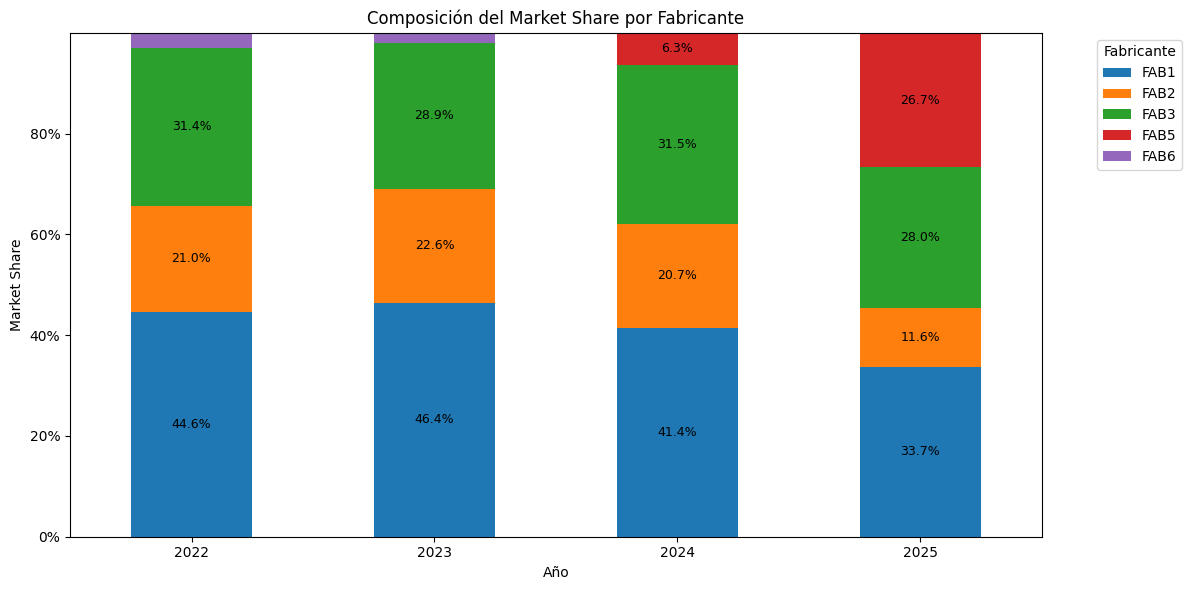

In [12]:
annual_sales = (
    monthly.groupby(['AÑO1', 'FABRICANTE'])
    ['VENTA_VALOR']
    .sum()
    .reset_index()
)

annual_sales['MARKET_SHARE'] = (
    annual_sales['VENTA_VALOR'] /
    annual_sales.groupby('AÑO1')['VENTA_VALOR']
    .transform('sum')
)

share_pivot = annual_sales.pivot(
    index='AÑO1',
    columns='FABRICANTE',
    values='MARKET_SHARE'
)

ax = share_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.title('Composición del Market Share por Fabricante')
plt.xlabel('Año')
plt.ylabel('Market Share')
plt.legend(
    title='Fabricante',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=0)

# Agregar porcentajes dentro de cada segmento
for container in ax.containers:
    labels = [
        f'{bar.get_height() * 100:.1f}%'
        if bar.get_height() > 0.03 else ''
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Observando el comportamiento del mercado, se interpreta que los principales competidores son el fabricnate 1,2 y 3. Tras 2024 y la llegada de Fabricante 5, los fabricantes principales comienzan a perder market share, especialmente el fabricante 2.

# Market Share en los últimos 12 meses

In [13]:
ultima_fecha = monthly['FECHAM'].max()

fecha_inicio = ultima_fecha - pd.DateOffset(months=11)

monthly_l12m = monthly[
    (monthly['FECHAM'] >= fecha_inicio) &
    (monthly['FECHAM'] <= ultima_fecha)
].copy()

product_sales = (
    monthly_l12m
    .groupby(['FABRICANTE','PRODUCTO'])['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)
product_share = (
    product_sales /
    product_sales.sum()
)
print("Market Share por producto (ultimos 12 meses)")
print(round(product_share,2))
print("")

product_share_cum = round(product_share.cumsum(),2)

print("Market Share acumulado por producto (ultimos 12 meses)")

print(product_share_cum)

Market Share por producto (ultimos 12 meses)
FABRICANTE  PRODUCTO                                 
FAB3        FAB3_1L  Ent Entera                          0.15
FAB1        FAB1_Leche Clasica Entera 1 L                0.12
            FAB1_Leche Clasica Deslactosada 1 L          0.12
FAB5        FAB5_Mm 12/1L Leche Ente Members Mark        0.11
FAB3        FAB3_1L  Desl Deslactosada                   0.11
FAB5        FAB5_Mm 12/1L Leche Desla Members Mark       0.10
FAB1        FAB1_Leche Clasica Deslactosada Light 1 L    0.06
FAB2        FAB2_ Deslac Deslactosada 1 L                0.04
            FAB2_12/1L  100 Proteina                     0.04
FAB1        FAB1_1L  Sele En Selecta Entera              0.04
FAB3        FAB3_1L  D Li Deslactosada Light             0.03
FAB2        FAB2_ Light Light 1L                         0.02
FAB1        FAB1_1L  Sel Des Deslactosada                0.02
FAB2        FAB2_ 100 Low C Arb                          0.01
            FAB2_ Des Light Desla

Realizando un análisis de Market Share a Nivel producto, se puede observar que los productos que conforman el 80% de market share en los últimos 12 meses son los siguientes:

1. FAB3_1L  Ent Entera                          0.15
2. FAB1_Leche Clasica Entera 1 L                0.12
3. FAB1_Leche Clasica Deslactosada 1 L          0.12
4. FAB5_Mm 12/1L Leche Ente Members Mark        0.11
5. FAB3_1L  Desl Deslactosada                   0.11
6. FAB5_Mm 12/1L Leche Desla Members Mark       0.10
7. FAB1_Leche Clasica Deslactosada Light 1 L    0.06
8. FAB2_ Deslac Deslactosada 1 L                0.04


El producto con el market share más alto es de 15%, siendo este del fabricante 3, Haciendo relación con el market share por fabricante, los fabricantes 3 y 5 son los directos competidores hacia el fabricante 1, ya que tiene casi la misma proporción de market share entre ellos. Los 3 fabricantes componen aproximadamente 88.4% del mercado en 2025. Es importante mencionar que el fabricante 3 y 5 contienen solo 3 productos y el fabricante 5 es la marca privada de la tienda.

## Correlación entre productos con mayor venta


Una vez analizados los productos con mayor market share del mercado, se buscaría hacer un análisis y observar si existe alguna relación entre los precios de estos productos para así tener mayor contexto de como compiten entre ellos en el mercado.

In [14]:
productos = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Entera 1 L',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB5_Mm 12/1L Leche Ente Members Mark',
    'FAB3_1L  Desl Deslactosada',
    'FAB5_Mm 12/1L Leche Desla Members Mark',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]



# Producto objetivo
target_product = 'FAB1_Leche Clasica Entera 1 L'

# Productos top a analizar
productos_corr = productos.copy()

# Asegurarnos de incluir el producto objetivo
if target_product not in productos_corr:
    productos_corr.append(target_product)

# Filtrar los productos seleccionados
corr_df = monthly_l12m[
    monthly_l12m['PRODUCTO'].isin(productos_corr)
].copy()

corr_df = corr_df.sort_values('FECHAM')

#Convertir a formato WIDE
precio_pivot = corr_df.pivot_table(
    index='FECHAM',
    columns='PRODUCTO',
    values='PPU_Litro',
    aggfunc='mean'
)

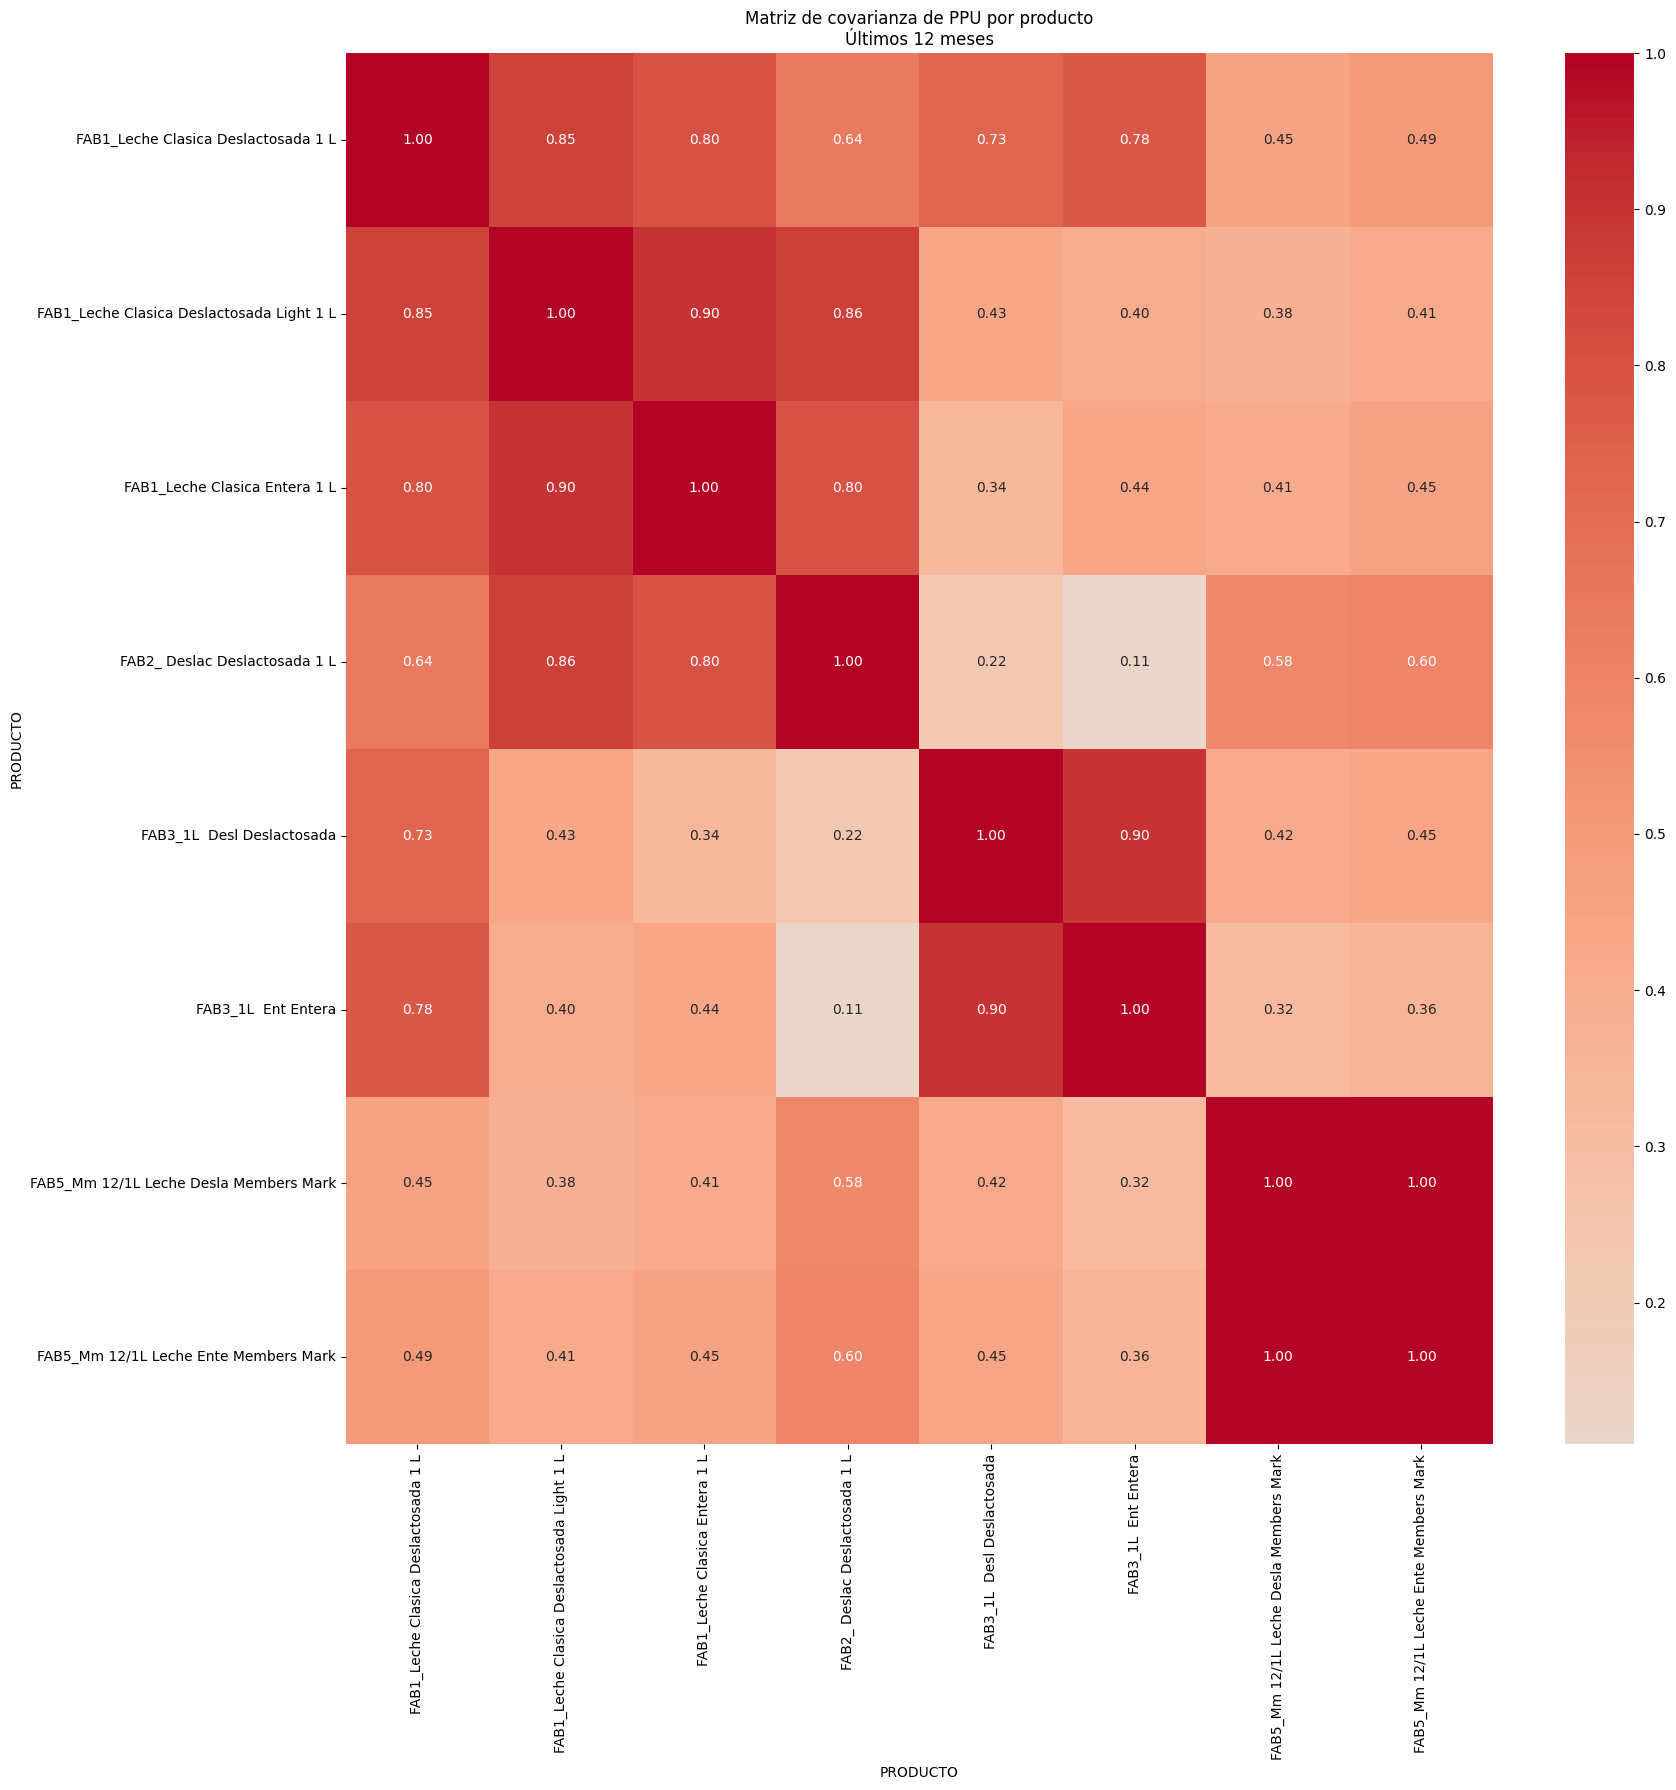

In [15]:
corr_precios = precio_pivot.corr()

corr_precios

plt.figure(figsize=(18, 18))
sns.heatmap(
    corr_precios,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de covarianza de PPU por producto\n'
    'Últimos 12 meses'
)

plt.tight_layout()
plt.show()



Respecto a la covarianza, se puede observar que todos los productos muestran una relación positiva entre una y la otra.

Esto da un primer indicador hacia la matriz de correlación para analizar sobre el comportamiento de cada precio respecto al de otro producto.

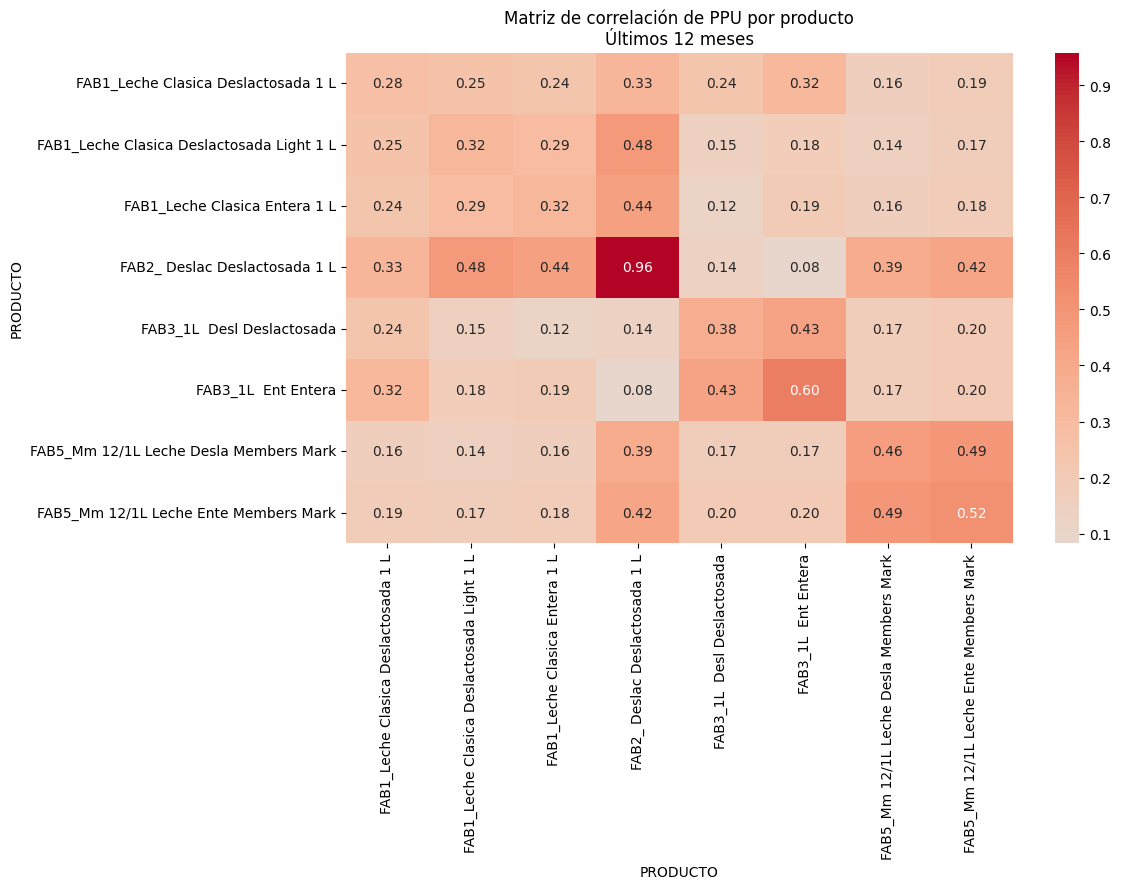

In [16]:
cov_precios = precio_pivot.cov()



plt.figure(figsize=(12, 9))

sns.heatmap(
    cov_precios,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Matriz de correlación de PPU por producto\n'
    'Últimos 12 meses'
)

plt.tight_layout()
plt.show()

Se puede observar en la matriz de correlación que si existen productos que tiene relación ligeramente alta entre ellos.

Esto también se puede tomar como indicio para predecir en los modelos que los precios entre los productos se comportan de una manera similar. En el caso de que algún producto suba o baje su precio, el de otro será propenso o probable que también lo haga.

Cabe mencionar que este análisis de correlación se hace respecto a los últimos 12 meses, lo cual se interpreta como una exploración inicial y no un indicio definitivo respecto a relación entre las variables.

# Análisis de Fabricante 1

In [17]:
fab1_l12m = monthly_l12m[
    monthly_l12m['FABRICANTE'] == 'FAB1'
]
product_sales = (
    fab1_l12m
    .groupby('PRODUCTO')['VENTA_VALOR']
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)


product_share = (
    product_sales /
    product_sales.sum()
)

print(round(product_share,2))

PRODUCTO
FAB1_Leche Clasica Entera 1 L                86884751.93
FAB1_Leche Clasica Deslactosada 1 L          85006585.93
FAB1_Leche Clasica Deslactosada Light 1 L    42840184.80
FAB1_1L  Sele En Selecta Entera              25018869.71
FAB1_1L  Sel Des Deslactosada                13399351.83
FAB1_Leche Clasica Extra Deslactosada 1 L     1951755.38
FAB1_Leche Clasica Light 1 L                   268755.67
FAB1_Leche Clasica Semi 1 L                     21450.00
Name: VENTA_VALOR, dtype: float64
PRODUCTO
FAB1_Leche Clasica Entera 1 L                0.34
FAB1_Leche Clasica Deslactosada 1 L          0.33
FAB1_Leche Clasica Deslactosada Light 1 L    0.17
FAB1_1L  Sele En Selecta Entera              0.10
FAB1_1L  Sel Des Deslactosada                0.05
FAB1_Leche Clasica Extra Deslactosada 1 L    0.01
FAB1_Leche Clasica Light 1 L                 0.00
FAB1_Leche Clasica Semi 1 L                  0.00
Name: VENTA_VALOR, dtype: float64


Analizando los productos de Fabricante 1, sus dos productos principales son la leche clasica entera y leche clasica deslactosada. Aunque ambos son muy parecidos y tienen un porcentaje bastante similar, se realizará un modelo de regresión lineal para el producto con mayor número de ventas, el cual es Leche Clasica Entera 1 L. Se buscará analizar y observar la elasticidad del producto y su relación respecto al volumen.

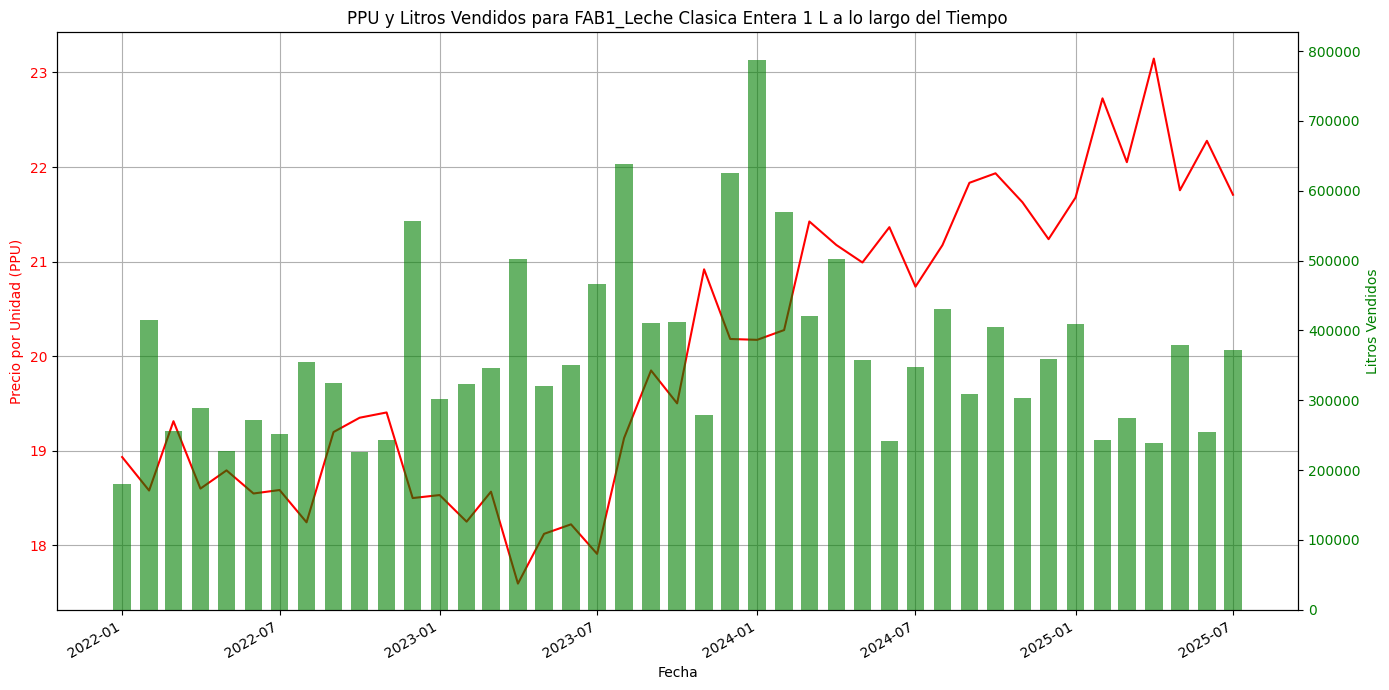

In [18]:
producto = 'FAB1_Leche Clasica Entera 1 L'

top_product = monthly[
    monthly['PRODUCTO'] == producto
].copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot PPU on the primary y-axis
ax1.plot(top_product['FECHAM'], top_product['PPU_Litro'], color='red', label='PPU')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio por Unidad (PPU)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True)

# Create a second y-axis for Units
ax2 = ax1.twinx()
ax2.bar(top_product['FECHAM'], top_product['LITROS'], color='green', alpha=0.6, width=20, label='Unidades Vendidas')
ax2.set_ylabel('Litros Vendidos', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('PPU y Litros Vendidos para FAB1_Leche Clasica Entera 1 L a lo largo del Tiempo')
fig.autofmt_xdate() # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Realizando una gráfica que indican los litros y el precio unitario a través del tiempo, inicialmente se puede observar que el producto puede llegar a tener patrones estacionales, como se puede observar en fin de año que se despunta la venta de unidades y existe un incremento que no puede solo ser asociado al precio de venta.


# Regresión Lineal de una variable


Para observar la elasticidad del modelo, se realizará el modelo en dos versiones, una es utilizando los coeficientes de manera natural, como vienen estructuradas en el dataset, y otra versión será utilizarla en su versión logarítmica.

De esta forma, se obtendrá la diferencia de forma porcentual, mientras que en el caso de coeficientes naturales se podrá observar cuanto volumen aumenta o disminuye.

## Version Lineal de regresión

In [19]:
import statsmodels.api as sm

X = top_product['PPU_Litro']
y = top_product['LITROS']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 LITROS   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.3721
Date:                Mon, 07 Sep 2026   Prob (F-statistic):              0.545
Time:                        14:32:43   Log-Likelihood:                -565.82
No. Observations:                  43   AIC:                             1136.
Df Residuals:                      41   BIC:                             1139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.248e+05    2.6e+05      2.021      0.0

Observando los resultados de la regresión lineal, se determina que el precio explica el 0.9% del volumen.

Analizando la predicción del modelo, se observa que el precio por litro indica que, cada peso que aumenta de precio, se estimaría una caída de  7,877 litros. También observando el estadístico t, se observa que no es un valor alto y el p-value es mayor a 0.5. Con esto se determina que, con la información del dataset, no se encuentra evidencia estadística significativa de una relación entre el precio y los litros vendidos.

## Versión logarítmica de regresión

In [20]:
top_product['log_litros'] = np.log(top_product['LITROS'])
top_product['log_ppu'] = np.log(top_product['PPU_Litro'])


X = top_product['log_ppu']
y = top_product['log_litros']

X = sm.add_constant(X)

elasticity_model = sm.OLS(y, X).fit()

print(elasticity_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_litros   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.2848
Date:                Mon, 07 Sep 2026   Prob (F-statistic):              0.596
Time:                        14:32:43   Log-Likelihood:                -11.504
No. Observations:                  43   AIC:                             27.01
Df Residuals:                      41   BIC:                             30.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8079      1.964      7.032      0.0

Analizando el modelo logarítmico, se observa que el precio del producto casi no explica el volumen de venta. Esto al tener un $R^2$ de 0.007 determina que tiene una relación prácticamente nula.


El coeficiente del PPU nos indica que si el precio unitario del producto sube un porciento, la venta en litros se reduce un 0.34%. Observando el p-value se obtiene un valor de 0.59 y con esto no se puede rechazar la hipotesis nula, que se define como que no existe una relación entre el precio y volumen. Esto va acorde a los resultados obtenidos en el modelo anterior.

También al observar que el valor de $|β_1| < 1$ se determina que, para el modelo, la demanda es inelástica. Es decir, que el volumen no se mueve proporcionalmente a lo que indica el precio del producto.

Al analizar el intervalo de confianza, se puede observar que este está entre [-1.673, 0.974]. Esto significa que no se puede determinar que la elasticidad sea negativa y que afecte de manera activa al volumen.

Aunque los modelos no sean los más efectivos, esto puede ser por la falta de más variables importantes, esto siendo llamado **variable omitida**. Esto se refiere a que se busca explicar toda la variabilidad del volumen utilizando solo el precio, cuando existen otros factores que pueden afectar y el hecho de no tener otra variable que ayude a explicar el volumen, hace que el precio no se pueda explicar de buena manera.

Ahora, sabiendo esto, se buscaría agregar el precio de los productos de competencia y la estacionalidad del año para buscar si ahí se encuentra un grupo de atributos que puedan mejorar este modelo y pueda predecirse de una manera acorde.

#Regresión Multivariable


Observando que la regresión para el precio por litro del producto principal no arroja un resultado óptimo o estadísticamente significativo, se realizará un segundo modelo de regresión pero ahora con múltiples variables.

Como es un contexto de mundo real, el precio no es el único factor que puede influir en el volumen vendido o en la demanda de litros en este caso.

Se puede relacionar también con promociones, relación entre los productos de competencia o incluso con un producto de la misma empresa, temporalidades, factores macro económicos, entre otros.

Para aumentar la explicatividad y relación repecto al modelo anterior, se implementará la misma regresión, pero incluyendo más variables que puedan mejorar el desempeño de este modelo.

Observando que llega a tener tendencias estacionales, se incluirán variables categóricas que corresponden a cada mes del año.

Como segundo moelo, se agregará un nivel de tendencia para observar si afecta un crecimiento tendencial al modelo y permite encontrar una explicabilidad más adecuada.

Posteriormente se buscará incluir el precio por unidad de los productos top de los últimos 12 meses.

#Versión logarítmica multivariada (solo estacionalidad)

In [21]:
reg_season = top_product.copy()
reg_season = reg_season.sort_values('FECHAM').copy()

reg_season = reg_season[
    (reg_season['LITROS'] > 0) &
    (reg_season['PPU_Litro'] > 0)
].copy()

# Transformaciones logarítmicas
reg_season['log_LITROS'] = np.log(reg_season['LITROS'])
reg_season['log_PPU'] = np.log(reg_season['PPU_Litro'])

# Crear variables dummy para los meses
reg_season = pd.get_dummies(
    reg_season,
    columns=['MES'],
    drop_first=True,
    dtype=int
)

y_season = reg_season['log_LITROS']
month_dummies = [
    col for col in reg_season.columns
    if col.startswith('MES_')
]

X_season = reg_season[['log_PPU'] + month_dummies]

# Agregar intercepto
X_season = sm.add_constant(X_season)

# Asegurar que todas las variables sean numéricas
X_season = X_season.astype(float)
y_season = y_season.astype(float)


# Modelo log-log con estacionalidad
model_season = sm.OLS(y_season, X_season).fit()

print(model_season.summary())



                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                 -0.039
Method:                 Least Squares   F-statistic:                    0.8695
Date:                Mon, 07 Sep 2026   Prob (F-statistic):              0.584
Time:                        14:32:43   Log-Likelihood:                -5.2363
No. Observations:                  43   AIC:                             36.47
Df Residuals:                      30   BIC:                             59.37
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.1725      2.019      6.524      0.0

Por funcionamiento de la función "get.dummies" de Python, escoge la variable categórica más pequeña y así se determina que la variable de referencia es Enero.


Interpretando el resultado de este modelo de regresión multivariada, el cual ya incluye el precio del producto junto con la estacionalidad, se puede observar que la $R^2$ aumentó a 0.258, aunque no llega a ser práctico debido a que se tiene un R ajustada de -0.039.

Observando el coeficiente de elasticidad, se observa que $β_1 = -0.1235$, lo cual nos da a entender que si aumenta 1% de precio, se disminuye aproximadamente 0.124% de litros de venta. Se sigue observando que $|β_1| < 1$, por lo que se sigue determinando que es una demanda inelástica. Al tener un p-value de 0.856, se concluye que no existe evidencia estadísticamente significativa para decir que el precio tiene un efecto distinto a 0 sobre los litros vendidos. A comparación del modelo anterior, se observa que el p-value ha aumentado y el intervalo de confianza es aún más amplio y todavía cubre el 0. Esto nos da a entender que se tiene cierta incertidumbre sobre el efecto de precio respecto a este producto.

Observando el cambio al agregar las estacionalidades, se observa que se distribuye la variación a los meses del año y eso permite que el coeficiente de $β_1$ se pueda explicar de una mejor manera, al no atribuirse valores que pueden esta relacionados a comportamientos estacionales.

# Regresión multivariada con estacionalidad + tendencia

In [22]:
reg_season = reg_season.sort_values('FECHAM').copy()

# Crear tendencia temporal
reg_season['trend'] = np.arange(len(reg_season))

# Variable dependiente
y_trend = reg_season['log_LITROS']

# Variables de estacionalidad
month_dummies = [
    col for col in reg_season.columns
    if col.startswith('MES_')
]

X_trend = reg_season[['log_PPU', 'trend'] + month_dummies]


X_trend = sm.add_constant(X_trend)


X_trend = X_trend.astype(float)
y_trend = y_trend.astype(float)

# Ejecutar modelo
model_trend = sm.OLS(y_trend, X_trend).fit()

print(model_trend.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     1.990
Date:                Mon, 07 Sep 2026   Prob (F-statistic):             0.0604
Time:                        14:32:43   Log-Likelihood:                 2.0559
No. Observations:                  43   AIC:                             23.89
Df Residuals:                      29   BIC:                             48.54
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.1850      3.655      6.617      0.0

Al agregar una tendencia de crecimiento al modelo, hubo un cambio drástico respecto a la explicabilidad del modelo.

Se observa que la $R^2$ aumentó a un 0.471 y su R ajustada a un 0.235. Esto demuestra que al agregar esta variable, se mejoró a comparación de los anteriores.

Analizando la elasticidad, el modelo muestra un coeficiente negativo de -3.9698, lo cual indica que un aumento de 1% de precio está asociado a una disminución aproximada de 3.97% de venta de litros. A diferencia de los modelos anteriores, este producto si muestra significancia estadística al tener un p-value menor a 0.05 y da evidencia estadísticamente significativa de que el producto si tiene una relación negativa respecto al producto. Cabe mencionar que el intervalo de confianza está entre [-6.555, -1.384], lo cual demuestra que se mentiene en un rango negativo y reafirma la suposición de tener relación negativa respecto al producto.

Analizando la variable de tendencia, se observa que el crecimiento promedio es aproximadamente de 2.61% por cada periodo mensual. Al tener un p-value de 0.002, se reafirma que el producto sigue una tendencia de crecimiento que los modelos anteriores no podían controlar de manera adecuada.

Respecto a la estacionalidad, se observa que no tienen evidencia estadísticamente significativa para demostrar que existen diferencias entre los meses y enero. Cabe mencionar que no significa que no exista diferencia entre los meses, simplemente con la información obtenida no se ha encontrado evidencia significativa para identificar estos meses individualmente con precisión.

# Regresión Multivariada con estacionalidad, tendencia y competencia


Una vez realizados los modelos anteriores, se buscaría hacer un modelo que incluya también los productos competencia, esto con el objetivo de observar una elasticidad cruzada y si afecta mucho el precio de otros productos a la venta de litros de nuestro producto principal.

In [23]:
# Producto objetivo
target_product = 'FAB1_Leche Clasica Entera 1 L'

# Competidores = productos top
competidores = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB5_Mm 12/1L Leche Ente Members Mark',
    'FAB3_1L  Desl Deslactosada',
    'FAB5_Mm 12/1L Leche Desla Members Mark',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]

In [24]:
# Filtrar productos objetivo + competidores
productos_modelo = [target_product] + competidores

df_modelo = monthly[
    monthly['PRODUCTO'].isin(productos_modelo)
].copy()

df_modelo = df_modelo.sort_values('FECHAM')

precios = df_modelo.pivot_table(
    index='FECHAM',
    columns='PRODUCTO',
    values='PPU_Litro',
    aggfunc='mean'
)

precios = precios.reset_index()
volumen = df_modelo[
    df_modelo['PRODUCTO'] == target_product
][['FECHAM', 'LITROS']].copy()

volumen = volumen.rename(
    columns={'LITROS': 'LITROS_TARGET'}
)

reg_comp = volumen.merge(
    precios,
    on='FECHAM',
    how='inner'
)

reg_comp = reg_comp.sort_values('FECHAM').copy()

reg_comp.head(35)

,FECHAM,LITROS_TARGET,FAB1_Leche Clasica Deslactosada 1 L,FAB1_Leche Clasica Deslactosada Light 1 L,FAB1_Leche Clasica Entera 1 L,FAB2_ Deslac Deslactosada 1 L,FAB3_1L Desl Deslactosada,FAB3_1L Ent Entera,FAB5_Mm 12/1L Leche Desla Members Mark,FAB5_Mm 12/1L Leche Ente Members Mark
0,2022-01-01,179628,17.894349,19.473101,18.933136,16.979174,18.624347,18.158429,NaN,NaN
1,2022-02-01,414468,16.954899,18.814841,18.578916,17.445016,19.400232,18.989434,NaN,NaN
2,2022-03-01,255948,17.885441,19.449479,19.312209,17.260064,18.787825,18.171513,NaN,NaN
3,2022-04-01,288564,17.845226,19.359474,18.599331,17.447897,20.004713,19.232643,NaN,NaN
4,2022-05-01,227664,18.782089,19.258161,18.792112,17.895156,19.797694,19.240419,NaN,NaN
5,2022-06-01,271176,18.813538,18.955294,18.547633,16.808192,19.528229,18.928353,NaN,NaN
6,2022-07-01,252108,18.788449,19.063637,18.584326,16.976531,20.066849,19.383002,NaN,NaN
7,2022-08-01,354252,18.796803,19.144642,18.242792,18.211054,18.990431,18.578119,NaN,NaN
8,2022-09-01,325308,19.461670,20.316775,19.197450,18.736484,19.668355,19.932079,NaN,NaN
9,2022-10-01,226236,19.750714,19.862350,19.348883,18.221290,19.411917,19.024303,NaN,NaN


Observando los productos de Fabricante 5, se observa que no existe información hasta Agosto de 2024.

En este contexto se pueden realizar dos cosas.

1. Reducir la información de Agosto de 2024 en adelante para capturar los precios de todos los productos competencia en los últimos 12 meses.
2. Excluirlos de la regresión multivariada.


En este caso, al darle prioridad al histórico, se eliminan estas dos columnas del dataset para permitir el uso de todo el histórico disponible.

In [25]:
reg_comp = reg_comp.drop(['FAB5_Mm 12/1L Leche Desla Members Mark', 'FAB5_Mm 12/1L Leche Ente Members Mark'], axis=1)
reg_comp

,FECHAM,LITROS_TARGET,FAB1_Leche Clasica Deslactosada 1 L,FAB1_Leche Clasica Deslactosada Light 1 L,FAB1_Leche Clasica Entera 1 L,FAB2_ Deslac Deslactosada 1 L,FAB3_1L Desl Deslactosada,FAB3_1L Ent Entera
0,2022-01-01,179628,17.894349,19.473101,18.933136,16.979174,18.624347,18.158429
1,2022-02-01,414468,16.954899,18.814841,18.578916,17.445016,19.400232,18.989434
2,2022-03-01,255948,17.885441,19.449479,19.312209,17.260064,18.787825,18.171513
3,2022-04-01,288564,17.845226,19.359474,18.599331,17.447897,20.004713,19.232643
4,2022-05-01,227664,18.782089,19.258161,18.792112,17.895156,19.797694,19.240419
5,2022-06-01,271176,18.813538,18.955294,18.547633,16.808192,19.528229,18.928353
6,2022-07-01,252108,18.788449,19.063637,18.584326,16.976531,20.066849,19.383002
7,2022-08-01,354252,18.796803,19.144642,18.242792,18.211054,18.990431,18.578119
8,2022-09-01,325308,19.461670,20.316775,19.197450,18.736484,19.668355,19.932079
9,2022-10-01,226236,19.750714,19.862350,19.348883,18.221290,19.411917,19.024303


In [26]:
competidores = [
    'FAB3_1L  Ent Entera',
    'FAB1_Leche Clasica Deslactosada 1 L',
    'FAB3_1L  Desl Deslactosada',
    'FAB1_Leche Clasica Deslactosada Light 1 L',
    'FAB2_ Deslac Deslactosada 1 L'
]

productos_modelo = [target_product] + competidores


reg_comp = reg_comp[
    reg_comp['LITROS_TARGET'] > 0
].copy()

reg_comp['log_LITROS'] = np.log(
    reg_comp['LITROS_TARGET']
)

for p in productos_modelo:
    reg_comp[f'log_P_{p}'] = np.log(
        reg_comp[p]
    )

In [27]:
#Tendencia
reg_comp['trend'] = np.arange(len(reg_comp))

#Variable de precio
precio_vars = [
    f'log_P_{p}'
    for p in productos_modelo
]
# Variables de precio
X_comp = reg_comp[precio_vars + ['trend']].copy()

# variables dummy de mes
reg_comp['MES'] = reg_comp['FECHAM'].dt.month
reg_comp = pd.get_dummies(
    reg_comp,
    columns=['MES'],
    drop_first=True,
    dtype=int
)

month_dummies = [
    col for col in reg_comp.columns
    if col.startswith('MES_')
]

X_comp = reg_comp[
    precio_vars + ['trend'] + month_dummies
]

X_comp = sm.add_constant(X_comp).astype(float)

y_comp = reg_comp['log_LITROS'].astype(float)

#Modelo
model_comp = sm.OLS(
    y_comp,
    X_comp
).fit()

print(model_comp.summary())

                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     1.237
Date:                Mon, 07 Sep 2026   Prob (F-statistic):              0.309
Time:                        14:32:44   Log-Likelihood:                 2.4561
No. Observations:                  43   AIC:                             33.09
Df Residuals:                      24   BIC:                             66.55
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

Para el modelo que incluye los productos top se observa un cambio respecto a la elasticidad del producto.
La variable de precio de nuestro producto principal se ve afectado respecto a su evidencia estadística y su coeficiente.

Aumentó a -4.1488, lo cual indica que un aumento de 1% de precio se predice a una disminución aproximada de 4.15% de venta de litros. Ahora, no se puede afirmar que esta elasticidad sea estadísticamente significativa ya que el p-value es de 0.178 y el intervalo de confianza nuevamente contiene a cero.

Observando los PPU's de los demás productos, se observa que algunos son de coeficiente positivo y otros negativo. También se puede observar que su p-value es mayor a 0.5, lo cual nos indica que ninguno tiene evidencia estadística para demostrar que su cambio de precio afecta la demanda de nuestro producto.


Una posible explicación sobre la pérdida de significancia en el modelo es la multicolinealidad entre los precios. Esto tiene sentido ya que se ha agregado productos que coexisten de una forma similar. Es decir, al tener productos que son del mismo fabricante, tienen un comportamiento bastante similar. Incluso generalizando esta categoría, se esperaría que los precios de los productos que pelean en una misma categoría tengan movimientos relacionados.


Observando el modelo en general, se tiene un $R^2$ de 0.48 y un R ajustado de 0.092. A comparación del modelo anterior, no ha mejorado la explicabilidad del modelo al observar la disminución de R ajustada.

# Predicción a futuro (24 meses)

Para poder predecir a futuro, se podría entender que un modelo de regresión puede ser adecuado, ya que permite observar los coeficientes que arroja el modelo y observar directamente que tanto afecta el aumento o disminución de alguna variable, como se observó anteriormente de los Precios y tendencias.


Ahora, algo que se considera importante es la relación tendencial en los meses acorde al producto. Existe una relevancia muy importante para los productos dependiendo de en que categoría compite y su estacionalidad con mayor relevancia.

Un ejemplo para esto es como los chocolates tienen picos altos de venta en Febrero y Mayo, esto por el 14 de Febrero y el día de las madres, respectivamente.


Ahora, sabiendo esto y entendiendo que este es una serie de tiempo, se ha investigado y existe un modelo llamado ARIMA, el cual tiene como propósito capturar correlaciones estacionarias en datos secuenciales. No se ha investigado a fondo pero podría considerarse una buena opción para la predicción.

Otro modelo que se ha encontrado es el VAR (Vector Autorregresivo) el cual busca encontrar relación y analizar variables que cambian y se afectan mutuamente, el cual podría ser el caso de la elasticidad cruzada o incluso la canibalización interna, el como un producto de mayor tamaño al reducir su precio podría afectar el producto a analizar.

Entrando más en concepto de Deep Learning, se podría utilizar una red neuronal que pueda encontrar patrones mucho más ocultos y no lineales entre los productos que permita predecir de una forma más especifica.


Todos estos modelos podrían ser adecuados, pero también es importante considerar cual utilizar acorde a como se comporte la categoría, el producto y sus competidores.